In [2]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

import scipy.sparse as sps
import scipy.sparse.linalg as spla
from scipy.optimize import brentq
from types import SimpleNamespace
import scipy.integrate as scpi
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid as trapz
import pandas as pd

from threedellips_morison import Beam3DMatrices, AddMooringSpringsGlobal

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Properties tunnel

In [ ]:
E = 40e9                #Pa 40GPa, take this as general value for Youngs modulus for C40/50 see appendix concrete hydraulic structures and offshore structures
G = 12e9 # https://eurocodeapplied.com/design/en1992/concrete-design-properties, shear modulus for this type of concrete

mooring_spacing = 25.0

#Ellipse outer axes
L_tunnel = 27000        # tunnel length [m]
ao = 14                 #m outer semi-major axis radius
ai = 13                 #m inner semi-major axis radius
bo = 8.5                #m outer semi-minor axis radius
bi = 7.5                #m inner semi-minor axis radius

rho_w   = 1025.0      # water density [kg/m3]
# rho_c   = 266.63 / 104.6242421   # structural density = m/A_tot [kg/m3] ###############
CD_y    = 0.5        # drag coefficient y-direction [-]
CD_z    = 1.5        # drag coefficient z-direction [-]
a_amp   = 1.5         # wave amplitude [m]
omega   = 2*np.pi/8.06        # wave frequency [rad/s]

mass = 266.63e3               # [kg/m]

#linear wave characteristics
Hs = 2.965
a = Hs / 2
T = 8.06
omega_w   = 2*np.pi/8.06 
d = 80
k_wave = 0.062

Atot = 104.6242421 #m2, including inner walls, calculated in excel

# Second moments of area for a hollow ellipse around the horizontal (major) and the vertical (minor) axis 
Iy = 3256.17 #m4, calculated in excel, including inner walls
Iz = 5950.91 #m4, calculated in excel, including inner walls

# Second moment of area for a hollow ellipse around the x-axis axis
Ix = (1/12)*L_tunnel * (2 *bo)**3 

#Polar moment of inertia for torsion, for a hollow ellipse, this is an approximation
J = Iy + Iz ##Unsure about this, if the torsion will deform the object in the yz plane should I thus take the  sum of Iy and Iz?

#radius of gyration for mass moment of inertia  [m^2] (should be * mass, but a function later takes it like this)
Im = ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))
# Im = mass * ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))

Beam_EIy = E*Iy   # bending about local y-axis, relevant for vertical z-deflection N.m2
Beam_EIz = E*Iz   # bending about local z-axis, relevant for horizontal y-deflection N.m2
Beam_EA = E * Atot                 # [N], wat do you take as A? also inner walls?
Beam_GJ = G * J            # [N.m2]?

# taut lines modelled as spring stiffnesses
ky = 2.03e6  # [N/m] horizontal stiffness
kz = 10.6e6  # [N/m] vertical stiffness
kyz = 0.102e6 # [N/m] coupled vertical and horizontal stiffness
kzy = 0.102e6 # [N/m] coupled vertical and horizontal stiffness

In [3]:
def FEMsolverscipy(Lsys, Lele, E, G, mooring_spacing, Iy, Iz, Ix, J, Im, Atot, mass, ky, kz, kyz, kzy, 
                   ao, ai, bo, bi, rho_w, CD_y, CD_z, Hs, T, omega_w, d, k_wave, m_part_target, n_periods):
    loop_StartTime = time.time()
    
    nEle_tunnel = int(round(Lsys / Lele))
    nNode = nEle_tunnel + 1
    Beam_EIy = E*Iy   
    Beam_EIz = E*Iz   
    Beam_EA = E * Atot                 
    Beam_GJ = G * J 
    Ele = [[i, i + 1, mass, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Im]
       for i in range(nNode - 1)]
    nEle = len(Ele)
    print('Element length: ', Lele)
    # print('Number of nodes: ', nNode)

    TunCX = np.linspace(0, Lsys, nNode)
    TunCY = np.zeros(nNode)
    TunCZ = -27.5 * np.ones(nNode) ## notice that its at a depth of 27.5m, so the z coordinate is -27.5m
    z_tunnel = -27.5
    NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]

    #build elemental matrices
    LDOF = 6
    nDof = LDOF * nNode  # 6 dof per node

    K = np.zeros((nDof, nDof))
    C = np.zeros((nDof, nDof))
    M = np.zeros((nDof, nDof))
    Q = np.zeros((nDof, nDof))

    for iEle in range(nEle):
        n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
        n1 = int(round(n1))
        n2 = int(round(n2))
        n1dof = LDOF * n1 + np.arange(LDOF)
        n2dof = LDOF * n2 + np.arange(LDOF)
        # Returns M, C, K, Q
        Me, Ce, Ke, Qe = Beam3DMatrices(
            m         = m,
            EA        = EA,
            EIy       = EIy,
            EIz       = EIz,
            GJ        = GJ,
            Im        = Im,
            NodeCoord = [NodeC[n1], NodeC[n2]],
            ky        = ky,
            kyz       = kyz,
            kzy       = kzy,
            kz        = kz,
            rho_w     = rho_w,
            ao        = ao,
            bo        = bo,
            CD_y      = CD_y,
            CD_z      = CD_z,
            a_amp     = a_amp,
            omega     = omega,
            rho_c     = 2500, ###
            A_tot     = Atot
        )

        indexes = np.append(n1dof, n2dof)
        for i in range(2 * LDOF):
            for j in range(2 * LDOF):
                M[indexes[i], indexes[j]] += Me[i, j]
                C[indexes[i], indexes[j]] += Ce[i, j]
                K[indexes[i], indexes[j]] += Ke[i, j]
                Q[indexes[i], indexes[j]] += Qe[i, j]
    # Add discrete mooring springs once globally
    x_nodes   = np.array([n[0] for n in NodeC])
    x_moorings = np.arange(x_nodes[0], x_nodes[-1] + mooring_spacing/2, mooring_spacing)

    mooring_nodes = np.array([np.argmin(np.abs(x_nodes - xm)) for xm in x_moorings])

    K = AddMooringSpringsGlobal(
        K, mooring_nodes, LDOF,
        ky, kyz, kzy, kz)
    
    # Boundary conditions: clamp both tunnel ends
    NodesClamp = (0, nNode - 1)

    # Prescribed DOFs
    DofsP = np.empty([0], dtype=int)
    for n0 in NodesClamp:
        DofsP = np.append(DofsP, n0 * LDOF + np.arange(0, LDOF))

    # Free DOFs
    DofsF = np.setdiff1d(np.arange(nDof), DofsP)

    # print("Prescribed DOFs:", DofsP)
    print("Number of free DOFs:", len(DofsF))

    # Use direct NumPy slicing instead of list-of-lists.
    # This avoids unnecessary Python loops and avoids converting back to arrays later.
    ff = np.ix_(DofsF, DofsF)
    M_FF = M[ff]
    K_FF = K[ff]
    C_FF = C[ff]
    Q_FF = Q[ff]
    Q_inertia_FF = Q_FF
    Q_drag_FF    = C_FF

    # plt.figure()
    # plt.spy(M_FF[:100, :100])
    # plt.title("Mass matrix")
    # plt.figure()
    # plt.spy(K_FF[:100, :100])
    # plt.title("Stiffness matrix")
    # plt.figure()
    # plt.spy(C_FF[:100, :100])
    # plt.title("Drag matrix")
    # plt.figure()
    # plt.spy(Q_FF[:100, :100])
    # plt.title("Excitation matrix")

    natfreq_StartTime = time.time()

    print('Finding natural frequencies')
    mat = np.dot(np.linalg.inv(M_FF), K_FF)
    w2, vr = np.linalg.eig(mat) #omega^2, eigenvectors
    w = np.sqrt(w2.real)
    f = w/2/np.pi               #natural frequencies
    # print(len(f))

    idx = f.argsort()           #sort freqencies, vectors and modal shapes in descending order
    f = f[idx]
    vr = vr[:,idx]      
    nMode = len(f)
    ModalShape = np.zeros((nDof, nMode))
    ModalShape[DofsF,:] = vr

    natfreq_EndTime = time.time()
    print(f'Natural frequency finding time: {natfreq_EndTime - natfreq_StartTime:.3f} s, or {(natfreq_EndTime - natfreq_StartTime)/60:.1f} min')

    # Mode selection based on excitation frequency
    # In this bit find which modes we want to use for reduced model and replaces nMode with it
    # Do not use this bit if you want to find the full response)

    f_force = 1 / T         # Hz
    f_cutoff = 2.0 * f_force   # guideline 1

    # Modes below cutoff frequency
    freq_modes = np.where(f <= f_cutoff)[0]

    if len(freq_modes) == 0:
        raise ValueError("No modes found below cutoff frequency.")

    nMode_freq = freq_modes[-1] + 1

    # print(f"Force frequency = {f_force:.5f} Hz")
    # print(f"Frequency cutoff = {f_cutoff:.5f} Hz")
    # print(f"Modes below cutoff = {nMode_freq}, frequency cutoff = 2 * {f_force:.5f} Hz = {f_cutoff:.5f} Hz")
    
    nMode = nMode_freq
    print('Nr of modes below cutoff frequency', nMode)

    # For now, damping added using Modal Damping Ratio. Not sure yet how our damping should be included.
    PHI = vr[:,0:nMode]

    quantile_StartTime = time.time()
    print('Calculate modal quantities')

    Mm = np.zeros(nMode)
    Km = np.zeros(nMode)
    Cm = np.zeros(nMode)
    ModalDampRatio = 0.01
    # Compute your "nMode" entries of the modal mass, stiffness and damping
    for iMode in np.arange(0,nMode):
        # print('Computing Mode: ',iMode+1) # Starts at 0 off course
        Mm[iMode] = PHI[:,iMode].T @ M_FF @ PHI[:,iMode]
        Km[iMode] = PHI[:,iMode].T @ K_FF @ PHI[:,iMode]
        Cm[iMode] = 2*ModalDampRatio*np.sqrt(Mm[iMode]*Km[iMode])
        # print('Mm = ',Mm[iMode],', Km = ', Km[iMode],', Cm = ', Cm[iMode])

    quantile_EndTime = time.time()
    print(f'quantile finding time: {quantile_EndTime - quantile_StartTime:.3f} s')

    # Effective mass participation criterion, change target to include more or less modes in nMode
    target = m_part_target

    # Influence vectors
    r_y = np.zeros(len(DofsF))
    r_z = np.zeros(len(DofsF))

    for iNode in range(nNode):
        global_v = iNode * LDOF + 1
        global_w = iNode * LDOF + 2

        if global_v in DofsF:
            r_y[np.where(DofsF == global_v)[0][0]] = 1.0

        if global_w in DofsF:
            r_z[np.where(DofsF == global_w)[0][0]] = 1.0

    total_mass_y = r_y.T @ M_FF @ r_y
    total_mass_z = r_z.T @ M_FF @ r_z

    eff_mass_y = np.zeros(nMode)
    eff_mass_z = np.zeros(nMode)

    for i in range(nMode):

        phi = PHI[:, i]

        Gamma_y = (phi.T @ M_FF @ r_y) / (phi.T @ M_FF @ phi)
        Gamma_z = (phi.T @ M_FF @ r_z) / (phi.T @ M_FF @ phi)

        eff_mass_y[i] = Gamma_y**2 * (phi.T @ M_FF @ phi)
        eff_mass_z[i] = Gamma_z**2 * (phi.T @ M_FF @ phi)

    cum_y = np.cumsum(eff_mass_y) / total_mass_y
    cum_z = np.cumsum(eff_mass_z) / total_mass_z

    # print(f"Cumulative Y participation: {cum_y[-1]:.4f}, Cumulative Z participation: {cum_z[-1]:.4f}")

    nMode_mass_y = np.searchsorted(cum_y, target) + 1
    nMode_mass_z = np.searchsorted(cum_z, target) + 1

    nMode = max(
        nMode_freq,
        nMode_mass_y,
        nMode_mass_z
    )
    
    print(f"Nr of modes included: {nMode}. Cutoff frequency: {f_cutoff:.5f} Hz. Mass participation y: {cum_y[-1]:.4f}. Mass participation z: {cum_z[-1]:.4f}.")

    # Define the boundary conditions and forcing(RHS).
    q0 = np.zeros(2 * nMode)

    # Airy waves
    factor_y = (a * omega_w**2 * np.cosh(k_wave * (d + z_tunnel)) / np.cosh(k_wave * d))
    factor_z = (a * omega_w**2 * np.sinh(k_wave * (d + z_tunnel)) / np.sinh(k_wave * d))

    def Vddot_global(t):
        """DOF order per node: [u, v, w, theta_x, theta_y, theta_z]    v = DOF 1 (horizontal y),  w = DOF 2 (vertical z)"""
        V = np.zeros(nDof)
        for iNode in range(nNode):
            dof_v = iNode * LDOF + 1   # horizontal y-acceleration acts on v DOF
            dof_w = iNode * LDOF + 2   # vertical   z-acceleration acts on w DOF
            V[dof_v] =  factor_y * np.cos(omega_w * t)
            V[dof_w] = -factor_z * np.sin(omega_w * t)   # minus: upward positive convention
        return V[DofsF]   # keep free DOFs only

    V_cos = np.zeros(nDof)   # amplitude of cos(wt) part
    V_sin = np.zeros(nDof)   # amplitude of sin(wt) part
    for iNode in range(nNode):
        V_cos[iNode * LDOF + 1] =  factor_y
        V_sin[iNode * LDOF + 2] = -factor_z
    V_cos_F = V_cos[DofsF]
    V_sin_F = V_sin[DofsF]

    # Modal force amplitudes:  shape (nMode,)
    Fm_cos = PHI.T @ (Q_FF @ V_cos_F)   # multiplies cos(omega*t)
    Fm_sin = PHI.T @ (Q_FF @ V_sin_F)   # multiplies sin(omega*t)

    def Fm(t):
        """Modal force vector at time t, shape (nMode,)"""
        return Fm_cos * np.cos(omega_w * t) + Fm_sin * np.sin(omega_w * t)

    def qdot(t, y):
        """RHS of the modal ODE system for solve_ivp. y[2r] = qr (modal displacement of mode r), y[2r+1] = q̇r (modal velocity of mode r)"""
        dydt = np.empty_like(y)
        fm = Fm(t)
        for r in range(nMode):
            qr  = y[2*r]
            dqr = y[2*r + 1]
            dydt[2*r]     = dqr
            dydt[2*r + 1] = (fm[r] - Cm[r]*dqr - Km[r]*qr) / Mm[r]
        return dydt

    n_periods = n_periods                 # reduced from 50
    points_per_period = 50         # reduced from 50

    t_eval = np.linspace(0.0, n_periods * T, n_periods * points_per_period + 1)

    FEM_StartTime = time.time()
    print('Solve SDOF systems')

    sol = scpi.solve_ivp(
        fun      = qdot,
        t_span   = (t_eval[0], t_eval[-1]),
        y0       = q0,
        t_eval   = t_eval,
        method   = 'DOP853',       # DOP853, or RK8, more accurate than RK45
    )
    q_modal  = sol.y[0::2, :]   # rows 0, 2, 4, ... → modal displacements, shape (nMode, nTime)
    qd_modal = sol.y[1::2, :]   # rows 1, 3, 5, ... → modal velocities,     shape (nMode, nTime)

    # Back-project to physical free DOFs
    x_phys = PHI @ q_modal      # shape (len(DofsF), nTime)

    q_time  = q_modal
    qd_time = qd_modal

    # print("Integration status:", sol.message)
    # print("Physical response shape:", x_phys.shape)
    t_last_start = sol.t[-1] - T
    idx_last = sol.t >= t_last_start
    t_last = sol.t[idx_last]
    q_last = q_time[:, idx_last]

    q_hat_modal  = (2.0 / T * np.trapezoid(q_last * np.exp(-1j * omega_w * t_last)[None, :],t_last,axis=1))

    x_hat_phys = PHI @ q_hat_modal

    # ── Reconstruct full displacement vector including constrained DOFs ───────
    n_time = len(sol.t)

    q_full_time = np.zeros((nDof, n_time))
    q_full_time[DofsF, :] = x_phys        # ← was q_time, which was modal-space

    v_dofs = np.arange(1, nDof, LDOF)
    w_dofs = np.arange(2, nDof, LDOF)

    v_time_nodes = q_full_time[v_dofs, :]
    w_time_nodes = q_full_time[w_dofs, :]

    q_hat_full = np.zeros(nDof, dtype=complex)
    q_hat_full[DofsF] = x_hat_phys

    # ── Node coordinates for plotting along tunnel ────────────────────────────
    try:
        x_nodes = np.asarray(NodeCoord)[:, 0]
    except:
        x_nodes = np.arange(len(v_dofs))

    # Midspan node for time-history plots
    mid_node = len(v_dofs) // 2

    # ── 1. Maximum absolute displacement over all nodes versus time ───────────
    max_v_time = np.max(np.abs(v_time_nodes), axis=0)
    max_w_time = np.max(np.abs(w_time_nodes), axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(sol.t, max_v_time, label=r'$\max |v|$ horizontal')
    plt.plot(sol.t, max_w_time, label=r'$\max |w|$ vertical')
    plt.axvline(sol.t[-1] - T, linestyle='--', label='start final period')
    plt.xlabel('Time [s]')
    plt.ylabel('Maximum displacement [m]')
    plt.title('Maximum tunnel displacement versus time')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── 2. Midspan displacement time history ──────────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(sol.t, v_time_nodes[mid_node, :], label=r'$v$ horizontal')
    plt.plot(sol.t, w_time_nodes[mid_node, :], label=r'$w$ vertical')
    plt.axvline(sol.t[-1] - T, linestyle='--', label='start final period')
    plt.xlabel('Time [s]')
    plt.ylabel('Midspan displacement [m]')
    plt.title('Midspan displacement time history')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── 3. Final-period steady-state response at midspan ──────────────────────
    idx_last = sol.t >= (sol.t[-1] - T)

    plt.figure(figsize=(8, 4))
    plt.plot(sol.t[idx_last], v_time_nodes[mid_node, idx_last], label=r'$v$ horizontal')
    plt.plot(sol.t[idx_last], w_time_nodes[mid_node, idx_last], label=r'$w$ vertical')
    plt.xlabel('Time [s]')
    plt.ylabel('Midspan displacement [m]')
    plt.title('Midspan response during final wave period')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── 4. Steady-state displacement amplitude along tunnel ───────────────────
    v_amp_nodes = np.abs(q_hat_full[v_dofs])
    w_amp_nodes = np.abs(q_hat_full[w_dofs])

    plt.figure(figsize=(8, 4))
    plt.plot(x_nodes, v_amp_nodes, label=r'$|\hat{v}|$ horizontal amplitude')
    plt.plot(x_nodes, w_amp_nodes, label=r'$|\hat{w}|$ vertical amplitude')
    plt.xlabel('Tunnel coordinate x [m]' if np.max(x_nodes) > len(x_nodes) else 'Node number [-]')
    plt.ylabel('Displacement amplitude [m]')
    plt.title('Estimated steady-state displacement amplitude along tunnel')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ── Print useful response quantities ──────────────────────────────────────
    print('Maximum response quantities:')
    print(f'Max |v(t)| over all nodes and times     = {np.max(np.abs(v_time_nodes)):.3f} m')
    print(f'Max |w(t)| over all nodes and times     = {np.max(np.abs(w_time_nodes)):.3f} m')
    print(f'Max |v_hat| steady-state amplitude      = {np.max(v_amp_nodes):.3f} m')
    print(f'Max |w_hat| steady-state amplitude      = {np.max(w_amp_nodes):.3f} m')
    print(f'Midspan |v_hat| steady-state amplitude = {v_amp_nodes[mid_node]:.3f} m')
    print(f'Midspan |w_hat| steady-state amplitude = {w_amp_nodes[mid_node]:.3f} m')

    FEM_EndTime = time.time()
    print(f'SDOF system solve time: {FEM_EndTime - FEM_StartTime:.3f} s, or {(FEM_EndTime - FEM_StartTime)/60:.1f} min')

    loop_EndTime = time.time()
    print(f'Element length {Lele} loop time: {loop_EndTime - loop_StartTime:.3f} s, or {(loop_EndTime - loop_StartTime)/60:.1f} min')

    print('\n')
    print('\n')

    return

Element length:  25.0
Number of free DOFs: 6474
Finding natural frequencies
Natural frequency finding time: 177.475 s, or 3.0 min
Nr of modes below cutoff frequency 172
Calculate modal quantities
quantile finding time: 9.467 s
Nr of modes included: 172. Cutoff frequency: 0.24814 Hz. Mass participation y: 0.9897. Mass participation z: 0.9924.
Solve SDOF systems


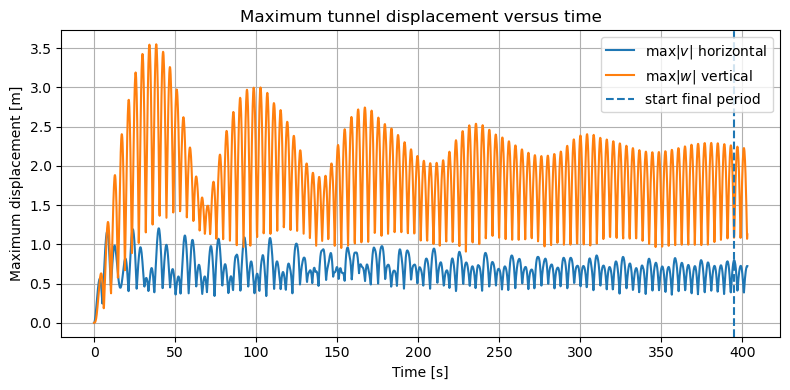

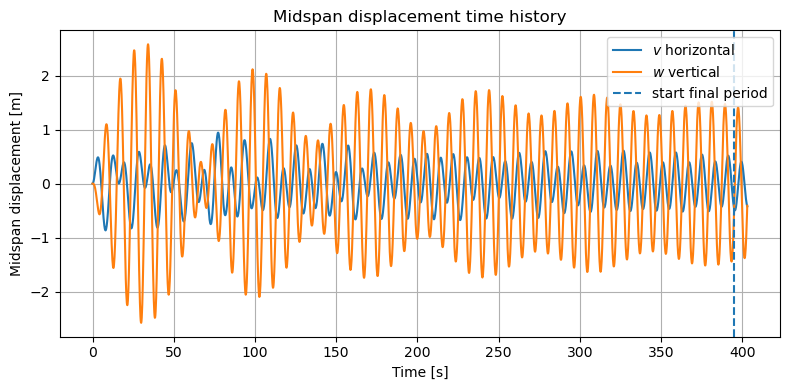

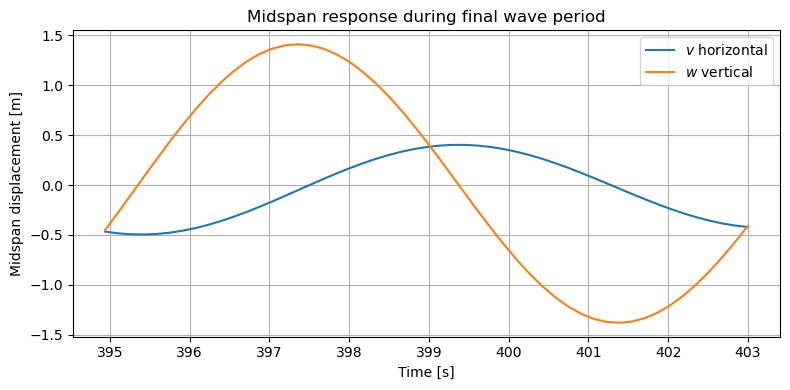

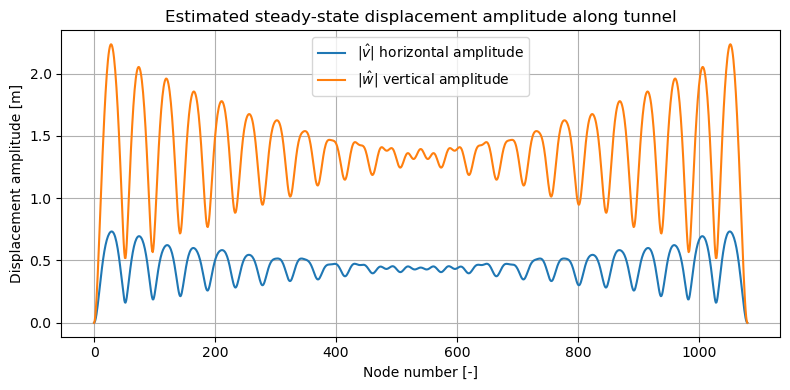

Maximum response quantities:
Max |v(t)| over all nodes and times     = 1.203 m
Max |w(t)| over all nodes and times     = 3.548 m
Max |v_hat| steady-state amplitude      = 0.733 m
Max |w_hat| steady-state amplitude      = 2.235 m
Midspan |v_hat| steady-state amplitude = 0.443 m
Midspan |w_hat| steady-state amplitude = 1.394 m
SDOF system solve time: 1.797 s, or 0.0 min
Element length 25.0 loop time: 216.961 s, or 3.6 min




Element length:  12.5
Number of free DOFs: 12954
Finding natural frequencies
Natural frequency finding time: 1261.588 s, or 21.0 min
Nr of modes below cutoff frequency 172
Calculate modal quantities
quantile finding time: 29.376 s
Nr of modes included: 172. Cutoff frequency: 0.24814 Hz. Mass participation y: 0.9891. Mass participation z: 0.9918.
Solve SDOF systems


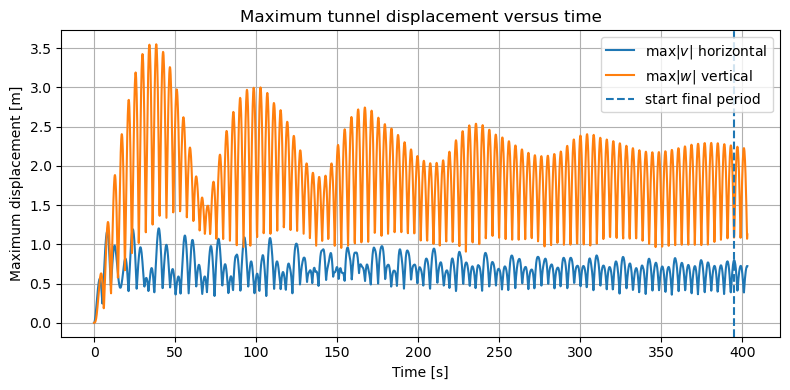

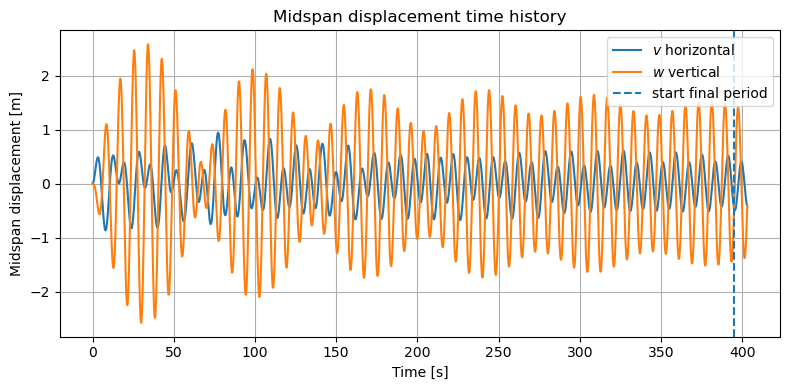

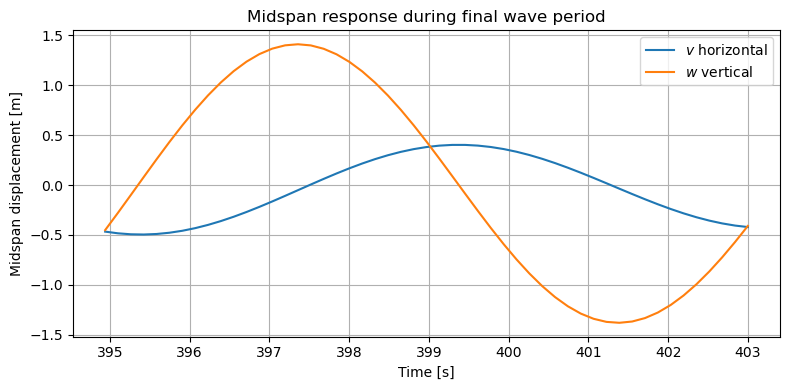

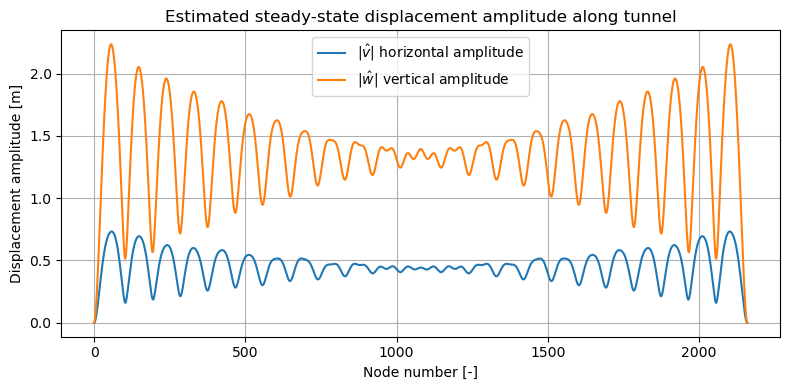

Maximum response quantities:
Max |v(t)| over all nodes and times     = 1.203 m
Max |w(t)| over all nodes and times     = 3.549 m
Max |v_hat| steady-state amplitude      = 0.733 m
Max |w_hat| steady-state amplitude      = 2.235 m
Midspan |v_hat| steady-state amplitude = 0.443 m
Midspan |w_hat| steady-state amplitude = 1.394 m
SDOF system solve time: 1.880 s, or 0.0 min
Element length 12.5 loop time: 1388.245 s, or 23.1 min




Element length:  5.0
Number of free DOFs: 32394


MemoryError: Unable to allocate 7.82 GiB for an array with shape (32394, 32394) and data type float64

In [ ]:
# Mesh convergence study settings
element_lengths = [25.0, 12.5]    # [m]
m_part_target = 0.98                        
n_periods = 50                              # nr of periods used in solving

for L_ele in element_lengths:
    FEMsolverscipy(27000, L_ele, E, G, mooring_spacing, Iy, Iz, Ix, J, Im, Atot, mass, ky, kz, kyz, kzy, 
                   ao, ai, bo, bi, rho_w, CD_y, CD_z, Hs, T, omega_w, d, k_wave, m_part_target, n_periods)


## Results convergence study

25 m element: In total took 3.6 minutes. \
Max |v(t)| over all nodes and times     = 1.203 m \
Max |w(t)| over all nodes and times     = 3.548 m \
Max |v_hat| steady-state amplitude      = 0.733 m \
Max |w_hat| steady-state amplitude      = 2.235 m \
Midspan |v_hat| steady-state amplitude = 0.443 m \
Midspan |w_hat| steady-state amplitude = 1.394 m 

12.5 m element: took 23.1 minutes. \
Max |v(t)| over all nodes and times     = 1.203 m \
Max |w(t)| over all nodes and times     = 3.549 m   --> + 1 mm \
Max |v_hat| steady-state amplitude      = 0.733 m \
Max |w_hat| steady-state amplitude      = 2.235 m \
Midspan |v_hat| steady-state amplitude = 0.443 m \
Midspan |w_hat| steady-state amplitude = 1.394 m \
--> shows minimal differences for 6.5 times the runtime. \
25 m is fine for element size.

5 m element creates a global matrix which is too large for my RAM, so it cannot be run.  \
Expectation is that it would take very long and show minimal to no improvements anyway.